In [2]:
from typing import TypedDict, Literal

class PortFolioState(TypedDict):    
    cash_usd: float
    total_usd: float
    total_eur: float
    stock: float
    stock_price: float
    stock_price_history: list[float]
    target_currency : Literal["usd", "eur"]

# class PortFolioAction(TypedDict):
    

In [3]:
alaki_obj : PortFolioState = {
    "cash_usd": 1000,
    "total_usd": 1000,
    "total_eur": 1000,
    "stock": 1000,
    "stock_price": 1000,
    "stock_price_history": [],
    "target_currency": "eur"
    }

In [4]:
def calc_total(state: PortFolioState) -> PortFolioState:
    state["total_usd"] = state["cash_usd"] + state["stock"] * state["stock_price"]
    state["total_eur"] = state["total_usd"] / 1.1
    return state


def convert_to_euro(state: PortFolioState) -> PortFolioState:
    state["total_eur"] = state["total_usd"] / 1.1
    return state

def choose_currency(state: PortFolioState) -> str:
    return state["target_currency"]


In [ ]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortFolioState)
builder.add_node("calc_total_node", calc_total)
builder.add_node("convert_to_euro_node", convert_to_euro)

builder.add_edge(START, "calc_total_node")  
builder.add_conditional_edges("calc_total_node", choose_currency, {"usd": "convert_to_euro_node", "eur": END})

graph = builder.compile()


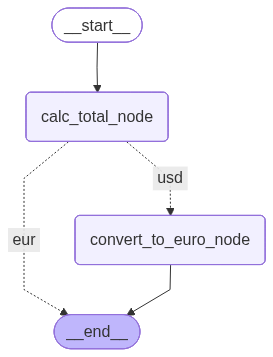

In [6]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
graph.invoke(alaki_obj)

{'cash_usd': 1000,
 'total_usd': 1001000,
 'total_eur': 909999.9999999999,
 'stock': 1000,
 'stock_price': 1000,
 'stock_price_history': [],
 'target_currency': 'eur'}

In [8]:
graph.invoke({"cash_usd": 100000, "stock": 3000, "stock_price": 4000, "target_currency": "usd"})

{'cash_usd': 100000,
 'total_usd': 12100000,
 'total_eur': 11000000.0,
 'stock': 3000,
 'stock_price': 4000,
 'target_currency': 'usd'}